## Create PCA for Victoria Data

In [1]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import glob
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
from sklearn import decomposition
import random 
from scipy import stats
from statsmodels.stats.multitest import multipletests
from skbio.stats.distance import DistanceMatrix
from scipy.spatial.distance import pdist, squareform
import skbio
from itertools import combinations
from scipy.stats import false_discovery_control
from skbio.stats.ordination import pcoa
from scipy.spatial.distance import cdist
from scipy.spatial import ConvexHull
from gprofiler import GProfiler
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

In [3]:
#import data
vic_dat = pd.read_excel('/home/mvoss/PEVIDS/PEVIDS_plasma/dat/meta-data/vic_data_for_moritz_final.xlsx')
pg_log2 = pd.read_csv('/home/mvoss/fromEmily/pg_matrix_imputed_nas_pycombat_batchcorr_missing_filt_70.0.csv')
meta_dat = pd.read_excel('/home/mvoss/Scrips_Bachelor_Thesis/Data/curated_metadata_pevids.xlsx')

In [4]:
#ignore warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    entb = pd.read_excel("/home/mvoss/Scrips_Bachelor_Thesis/Data/entblindungsliste_20250923.xlsx" , engine="openpyxl")
    zuord = pd.read_excel("/home/mvoss/Scrips_Bachelor_Thesis/Data/zuordnung_vic_zu_mir_ids.xlsx", engine="openpyxl")

In [5]:
#filter Data only from Victoria (data_source)
victoria_ids = meta_dat[meta_dat['data_source']=='victoria']
victoria_ids.drop_duplicates()

victoria_ids.shape


(662, 12)

In [6]:
#extract and add pnum
pg_log2['pnum'] = pg_log2['name_from_intensity'].str.extract(r'(P\d+)')
#print(pg_log2['pnum'].unique()) ## looks right


In [7]:
#pg_log2.head()

In [8]:
#make proteins row and samples columns
pg_int = pg_log2.T.filter(regex ="[0-9]", axis =1) ## making samples columns 
pg_int.columns = pg_int.iloc[0]
#pg_int.head()
pg_int = pg_int.drop("name_from_intensity")
pg_int.shape
#pg_int


(329, 1212)

In [9]:
#vic_dat.head()

In [10]:
victoria_pnums = victoria_ids['P_number'].tolist()
#pg_vic = pg_transformed[pg_transformed["p_key"].isin(merged_data['P_number'])]
pg_vic = pg_log2[pg_log2['pnum'].isin(victoria_pnums)]
#pg_vic.head()
pg_vic.shape #(579, 330)


(579, 330)

In [11]:
pg_vic['plate_num'] = pg_vic.apply(lambda x:  x['name_from_intensity'].split("_")[0], axis = 1)
#pg_vic.head()

/tmp/ipykernel_85962/3334504958.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pg_vic['plate_num'] = pg_vic.apply(lambda x:  x['name_from_intensity'].split("_")[0], axis = 1)


In [12]:
## get min intensity value
pg_vic.index = pg_vic['name_from_intensity']
vic_intensitites = pg_vic.filter(regex="[0-9]", axis = 1)
min_intensity = min(i for i in vic_intensitites.stack().sort_values().head(n=5) if i > 0)     ## needs for whole DF!! 
print("Minimum detected intensity greater than zero: ", min_intensity)

Minimum detected intensity greater than zero:  7.12032436392755


In [13]:
## check before pca is NAs somehow still there
pg_vic.loc[pg_vic.isna().any(axis = 1)]

,name_from_intensity,A0A075B6H7,A0A075B6H9,A0A075B6I0,A0A075B6I1,A0A075B6I9,A0A075B6J9,A0A075B6K4,A0A075B6K5,A0A075B6P5,...,Q9NQ79,Q9NZP8,Q9UGM5,Q9UHG3,Q9UK55,Q9Y5Y7,Q9Y6R7,batch_info,pnum,plate_num
name_from_intensity,,,,,,,,,,,,,,,,,,,,,


In [14]:
#get the treatment id option from the ent file: 
treat_id = pd.read_excel("/home/mvoss/Scrips_Bachelor_Thesis/Data/entblindungsliste_20250923.xlsx", engine="openpyxl")

#treat_id.head()
victoria_ids = pd.merge(victoria_ids, treat_id, on = "R_ID", how = "left")
#victoria_ids.head()

In [15]:
# fix extra space in victoria_ids file column
victoria_ids['file'] = victoria_ids['file'].str.replace(r'_\s+', '_', regex=True)

# clean and merge
victoria_ids_clean = victoria_ids.dropna(subset=['file']).drop_duplicates(subset='file')

pg_vic_merged = pg_vic.copy()
pg_vic_merged['file_clean'] = pg_vic_merged['name_from_intensity'].str.extract(r'(.*_R\d+)')

pg_vic_merged = pg_vic_merged.merge(
    victoria_ids_clean[['file', 'Alllocation', 'Messzeitpunkt']],
    left_on='file_clean',
    right_on='file',
    how='left'
)

In [16]:
victoria_ids.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
657    False
658    False
659    False
660    False
661    False
Length: 662, dtype: bool

victoria_ids

In [19]:

#victoria_ids[victoria_ids.duplicated('file', keep=False) == True] ## are duplicates due to weird merged behavior?


are duplicate file column values from the Unnamed column? weird merge behavior w/ index in df 

In [20]:
#drop duplicates in victoria_ids
victoria_ids_clean = victoria_ids.dropna(subset=['file']).drop_duplicates(subset='file')

print("victoria_ids original:", len(victoria_ids))
print("victoria_ids cleaned:", len(victoria_ids_clean))

#merge
pg_vic_merged = pg_vic.copy()
pg_vic_merged['file_clean'] = pg_vic_merged['name_from_intensity'].str.extract(r'(.*_R\d+)')

pg_vic_merged = pg_vic_merged.merge(
    victoria_ids_clean[['file', 'Alllocation', 'Messzeitpunkt']],
    left_on='file_clean',
    right_on='file',
    how='left'
)

#check
print("pg_vic shape:", pg_vic.shape)
print("pg_vic_merged shape:", pg_vic_merged.shape)

victoria_ids original: 662
victoria_ids cleaned: 580
pg_vic shape: (579, 331)
pg_vic_merged shape: (579, 335)


## PCA colored by time, allocation and plate

In [21]:
def apply_pca(dat, file_str="", hue_col='plate_num', palette=None):
    df_t = dat.copy()
    df_t.index = df_t['name_from_intensity']
    df_t_int = df_t.filter(regex="[0-9]", axis=1)
    
    pca = decomposition.PCA(n_components=2)
    pca.fit(df_t_int)
    pc = pca.transform(df_t_int)
    
    pc_df = pd.DataFrame(
        data=pc,
        columns=['pc1', 'pc2'],
        index=df_t[hue_col]
    )
    
    if palette is None:
        n = len(dat[hue_col].unique())
        palette = sns.color_palette("tab20b", n)
        print(f"there are a total of {n} unique {hue_col}s.")
    df_name = str(file_str)
    ax = sns.scatterplot(data=pc_df, x=pc_df["pc1"], y=pc_df["pc2"], hue=pc_df.index, alpha=0.8, palette=palette)
    plt.axhline(y=0, color="black", ls="--", alpha=0.7)
    plt.axvline(x=0, color="black", ls="--", alpha=0.7)
    plt.xlabel(f'PC1 ({int(pca.explained_variance_ratio_[0]*100)}%)', fontsize=14)
    plt.ylabel(f'PC2 ({int(pca.explained_variance_ratio_[1]*100)}%)', fontsize=14)
    #ax.set_title(f"PCA: {df_name}", fontsize=16)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize=12, title_fontsize=13)
    plt.axis('equal')
    ax.figure.savefig(f"Serum_victoria_pca_{df_name}.png", bbox_inches='tight')

there are a total of 11 unique plate_nums.


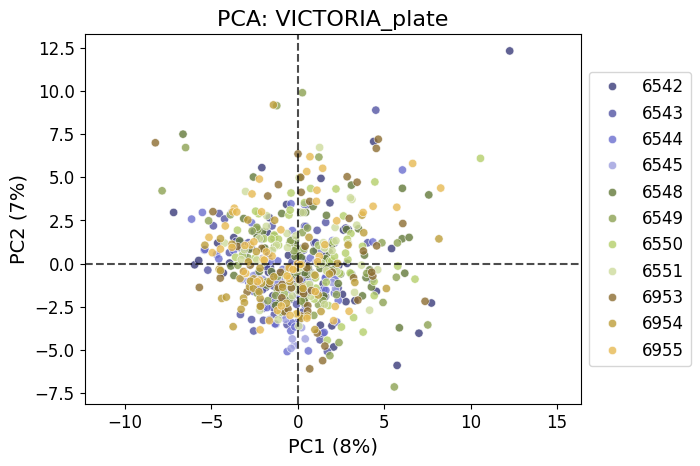

In [21]:
# colored by plate (auto palette)
apply_pca(pg_vic_merged, "VICTORIA_plate")


In [22]:
display(pg_vic_merged['Messzeitpunkt'].value_counts())

Messzeitpunkt
1.0    311
3.0    187
2.0     81
Name: count, dtype: int64

In [23]:
treatment = pg_vic_merged[pg_vic_merged['Messzeitpunkt'] == 3.0].reset_index(drop=True)

display(treatment.shape)

(187, 335)

In [24]:
treatment_2 = pg_vic_merged[pg_vic_merged['Messzeitpunkt'] == 2.0].reset_index(drop=True)

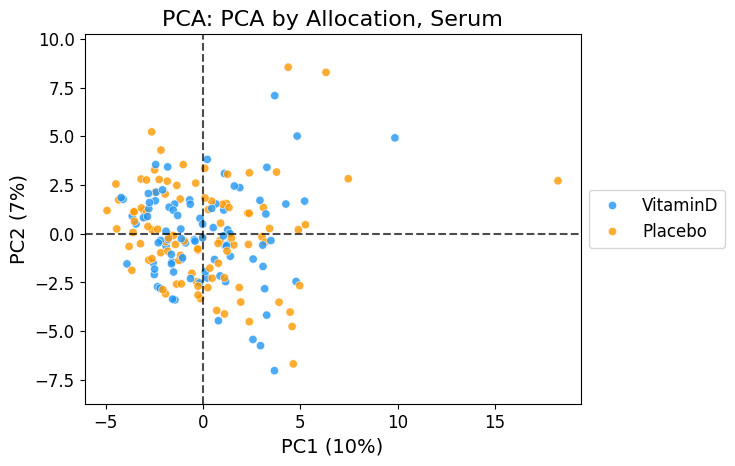

In [25]:
# colored by allocation
apply_pca(treatment, "PCA by Allocation, Serum", hue_col='Alllocation', palette={
    'VitaminD': '#2196F3',
    'Placebo':  '#FF9800',
})



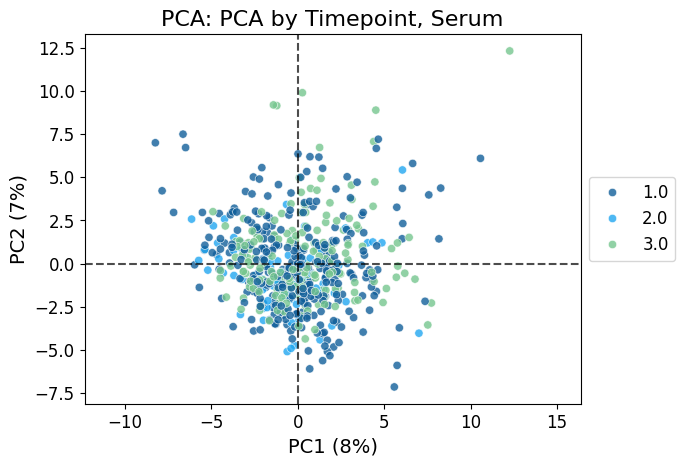

In [26]:
# colored by Messzeitpunkt
apply_pca(pg_vic_merged, "PCA by Timepoint, Serum", hue_col='Messzeitpunkt', palette={
    1.0: '#115f9a',
    2.0: '#22a7f0',
    3.0: '#76c68f',
})

In [22]:
display(pg_vic_merged['Messzeitpunkt'].value_counts())

Messzeitpunkt
1.0    311
3.0    187
2.0     81
Name: count, dtype: int64

In [23]:
display(pg_vic_merged['Alllocation'].value_counts())

Alllocation
Placebo     294
VitaminD    285
Name: count, dtype: int64

## Kruskal

The Kruskal-Wallis H-test tests the null hypothesis that the population median of all of the groups are equal. It is a non-parametric version of ANOVA. The test works on 2 or more independent samples, which may have different sizes. Note that rejecting the null hypothesis does not indicate which of the groups differs. Post hoc comparisons between groups are required to determine which groups are different.
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html

In [24]:
#metadata columns
meta_cols = ['name_from_intensity', 'pnum', 'plate_num','file_clean', 'file', 'Alllocation', 'Messzeitpunkt']

#protein columns = everything that's not metadata
protein_cols = [col for col in pg_vic_merged.columns if col not in meta_cols]

#protein columns to numeric, coercing strings to NaN
pg_vic_merged[protein_cols] = pg_vic_merged[protein_cols].apply(pd.to_numeric, errors='coerce')

#check
print(pg_vic_merged[protein_cols].dtypes.value_counts())

float64    328
Name: count, dtype: int64


In [25]:
#pg_vic_merged.head()

from emily: protein_cols vs pg_int ?? 

In [26]:
## bfrom emily: running an anova on TIMEPOINT only to see if timepoint is significantly associated with any individual protein
## however this is still an ANOVA and i believe we fail to meet the assumptions for anova
## also, one way anoiva? which direction? why? this needs to be two way 

##do kruskal test = extention on Mann Whitney U test 
##is for 3 or more independent groups
#filter messzeitpunkt 1 and Messszeitpunkt 2
kruskal_data = pg_vic_merged[pg_vic_merged['Messzeitpunkt'].isin([1.0, 3.0])]
results = []
for protein in protein_cols:
    group1 = kruskal_data[kruskal_data['Messzeitpunkt'] == 1.0][protein]
    group3 = kruskal_data[kruskal_data['Messzeitpunkt'] == 3.0][protein]
    
    stat, p = stats.kruskal(group1, group3)
    results.append({'protein': protein, 'stat': stat, 'p_value': p})

kruskal_results = pd.DataFrame(results).sort_values('p_value')
# how many NaN p-values?
#print(kruskal_results['p_value'].isna().sum())
#we have one NaN which needs to be dropped before p value adjustment
kruskal_results = kruskal_results.dropna(subset=['p_value'])

reject, p_adj, _, _ = multipletests(kruskal_results['p_value'], method='fdr_bh')
kruskal_results['p_adj'] = p_adj
kruskal_results['significant'] = reject

# significant hits only
print(f"Total proteins tested: {len(kruskal_results)}")
print(f"Significant after FDR correction: {kruskal_results['significant'].sum()}")
print(f"Proportion significant: {kruskal_results['significant'].mean():.1%}")
kruskal_results[kruskal_results['significant']].sort_values('p_adj')

Total proteins tested: 327
Significant after FDR correction: 46
Proportion significant: 14.1%


,protein,stat,p_value,p_adj,significant
134,P02751,103.848499,2.183931e-24,7.141456e-22,True
178,P06727,52.487606,4.329721e-13,7.079094e-11,True
160,P04275,49.702376,1.789291e-12,1.582204e-10,True
302,Q16610,49.548358,1.935418e-12,1.582204e-10,True
139,P02766,43.075704,5.266218e-11,3.444106e-09,True
124,P02671,34.649785,3.946822e-09,2.151018e-07,True
165,P05154,28.578966,8.995406e-08,4.202140e-06,True
176,P06396,27.469276,1.596101e-07,6.238984e-06,True
274,P59665,27.327907,1.717152e-07,6.238984e-06,True
311,Q92954,22.824322,1.775051e-06,5.804417e-05,True


from emily: you want a volcano plot with your u-test results. 


In [27]:
# calculate log2 fold change  = difference in medians
fold_changes = []
for protein in kruskal_results['protein']:
    med1 = kruskal_data[kruskal_data['Messzeitpunkt'] == 1.0][protein].median()
    med3 = kruskal_data[kruskal_data['Messzeitpunkt'] == 3.0][protein].median()
    log2fc = med3 - med1
    fold_changes.append(log2fc)

kruskal_results['log2fc'] = fold_changes
kruskal_results['log2fc'] = fold_changes
kruskal_results['-log10_p_adj'] = -np.log10(kruskal_results['p_adj'])

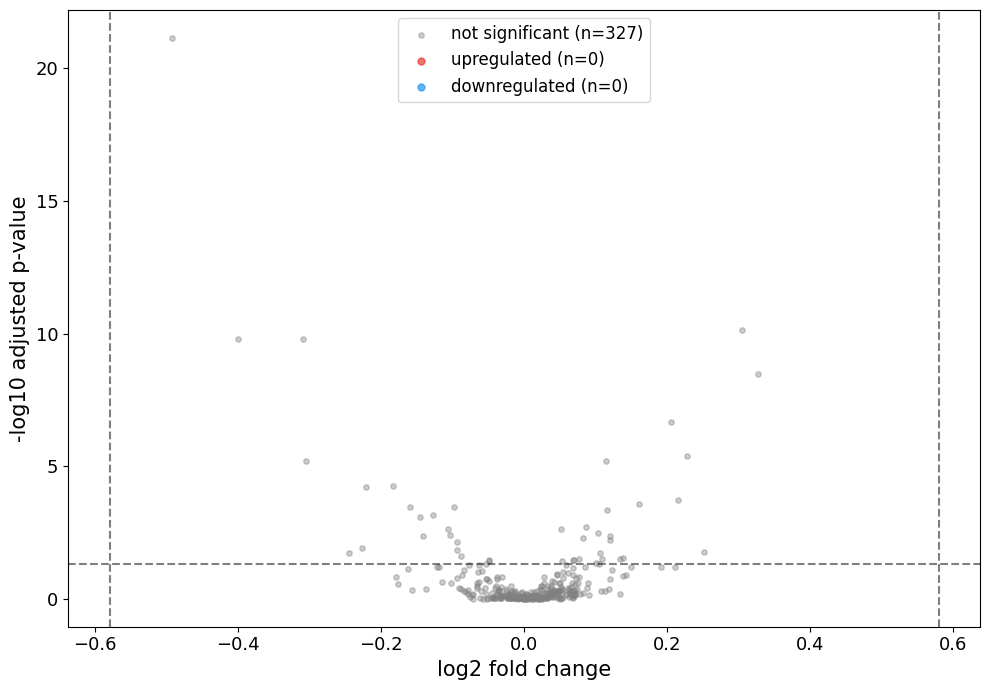

In [28]:
FC_THRESH = 0.58
PVAL_THRESH = 0.05
def classify(row):
    if not row['significant'] or abs(row['log2fc']) < FC_THRESH:
        return 'not significant'
    elif row['log2fc'] > FC_THRESH:
        return 'upregulated'
    else:
        return 'downregulated'
kruskal_results['direction'] = kruskal_results.apply(classify, axis=1)
color_map = {
    'not significant': 'grey',
    'upregulated':     '#E53935',
    'downregulated':   '#2196F3',
}
fig, ax = plt.subplots(figsize=(10, 7))
for group, color in color_map.items():
    subset = kruskal_results[kruskal_results['direction'] == group]
    ax.scatter(subset['log2fc'], subset['-log10_p_adj'],
               color=color, alpha=0.7 if group != 'not significant' else 0.4,
               s=25 if group != 'not significant' else 15,
               label=f"{group} (n={len(subset)})")
ax.axhline(y=-np.log10(PVAL_THRESH), color='black', ls='--', alpha=0.5)
ax.axvline(x= FC_THRESH, color='black', ls='--', alpha=0.5)
ax.axvline(x=-FC_THRESH, color='black', ls='--', alpha=0.5)
for _, row in kruskal_results[kruskal_results['direction'] != 'not significant'].iterrows():
    ax.annotate(row['protein'], xy=(row['log2fc'], row['-log10_p_adj']),
                fontsize=10, ha='left', va='bottom')
ax.set_xlabel('log2 fold change', fontsize=15)
ax.set_ylabel('-log10 adjusted p-value', fontsize=15)
#ax.set_title('Volcano plot: Baseline vs End of Study', fontsize=17)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig("volcano_messzeitpunkt_BLvsT3.png", dpi=150)
plt.show()

In [29]:
kruskal_results['log2fc'].describe()

count    327.000000
mean       0.005223
std        0.086513
min       -0.492324
25%       -0.032097
50%        0.008406
75%        0.049412
max        0.326828
Name: log2fc, dtype: float64

In [30]:
#significant proteins --> list
sig_proteins = kruskal_results[kruskal_results['significant']]['protein'].tolist()
#print('\n'.join(protein_cols))

In [31]:
#kruskal_data.head()

Plotting of significant proteins with Boxplot for visualization between baseline and end of trial

## GProfiler

controlling the background of the GProfiler with protein cols list

do you need to convert these proteins (sig_proteins or protein_cols) to match a specific DB? No

I NOTICE IT SAYS 194 TERMS FOUND AFTER GPROFILER RUN 

In [33]:
len(protein_cols) #328 

328

In [109]:
gp = GProfiler(return_dataframe=True)

print(f"Submitting {len(sig_proteins)} proteins to gProfiler")

enrichment = gp.profile(
    organism='hsapiens',
    query=sig_proteins,
    sources=['GO:BP', 'GO:MF', 'GO:CC', 'KEGG', 'REAC', 'WP', 'MIRNA', 'HPA', 'CORUM', 'HP'],
    significance_threshold_method='fdr',
    user_threshold=0.05,
    background=list(protein_cols)  # all 327 proteins measured
)

print(f"Enriched terms found: {len(enrichment)}")
print(enrichment['source'].value_counts())
enrichment.sort_values('p_value').head(20)

Submitting 46 proteins to gProfiler
Enriched terms found: 54
source
GO:CC    25
HP       21
CORUM     2
WP        2
GO:MF     2
MIRNA     1
GO:BP     1
Name: count, dtype: int64


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:CC,GO:0012505,endomembrane system,0.000057,True,"""A collection of membranous structures involve...",119,38,27,363,0.710526,0.226891,query_1,[GO:0110165]
1,GO:CC,GO:0031410,cytoplasmic vesicle,0.000057,True,"""A vesicle found in the cytoplasm of a cell."" ...",91,38,23,363,0.605263,0.252747,query_1,"[GO:0005737, GO:0097708]"
2,GO:CC,GO:0097708,intracellular vesicle,0.000057,True,"""Any vesicle that is part of the intracellular...",91,38,23,363,0.605263,0.252747,query_1,"[GO:0031982, GO:0043231]"
3,GO:CC,GO:0030141,secretory granule,0.000058,True,"""A small subcellular vesicle, surrounded by a ...",71,38,20,363,0.526316,0.281690,query_1,"[GO:0012505, GO:0099503]"
4,GO:CC,GO:0099503,secretory vesicle,0.000061,True,"""A cytoplasmic, membrane bound vesicle that is...",72,38,20,363,0.526316,0.277778,query_1,[GO:0031410]
5,GO:CC,GO:0060205,cytoplasmic vesicle lumen,0.000089,True,"""The volume enclosed by a cytoplasmic vesicle....",62,38,18,363,0.473684,0.290323,query_1,"[GO:0031410, GO:0031983, GO:0070013]"
6,GO:CC,GO:0031983,vesicle lumen,0.000089,True,"""The volume enclosed by the membrane or protei...",62,38,18,363,0.473684,0.290323,query_1,"[GO:0031982, GO:0043233]"
7,GO:CC,GO:0034774,secretory granule lumen,0.000089,True,"""The volume enclosed by the membrane of a secr...",62,38,18,363,0.473684,0.290323,query_1,"[GO:0030141, GO:0060205]"
8,GO:CC,GO:0005737,cytoplasm,0.000622,True,"""The contents of a cell excluding the plasma m...",152,38,28,363,0.736842,0.184211,query_1,"[GO:0005622, GO:0110165]"
9,GO:CC,GO:0005615,extracellular space,0.001303,True,"""That part of a multicellular organism outside...",251,38,36,363,0.947368,0.143426,query_1,"[GO:0005576, GO:0110165]"


how is the thing below different from the above? reducing the databases? 

In [110]:
# How many terms per source?
print(enrichment['source'].value_counts())

# Get the more specific/interesting terms (smaller term_size = more specific)
specific = enrichment[enrichment['term_size'] < 100].sort_values('p_value')
print(f"\nMore specific terms: {len(specific)}")
print(specific[['source', 'name', 'p_value', 'term_size', 'intersection_size']].head(20))

source
GO:CC    25
HP       21
CORUM     2
WP        2
GO:MF     2
MIRNA     1
GO:BP     1
Name: count, dtype: int64

More specific terms: 31
   source                                     name   p_value  term_size  \
1   GO:CC                      cytoplasmic vesicle  0.000057         91   
2   GO:CC                    intracellular vesicle  0.000057         91   
3   GO:CC                        secretory granule  0.000058         71   
4   GO:CC                        secretory vesicle  0.000061         72   
5   GO:CC                cytoplasmic vesicle lumen  0.000089         62   
6   GO:CC                            vesicle lumen  0.000089         62   
7   GO:CC                  secretory granule lumen  0.000089         62   
15  CORUM                               CORUM root  0.002172         49   
20     WP      Network map of SARS CoV 2 signaling  0.002778         41   
30  GO:CC                    endoplasmic reticulum  0.010614         61   
32  GO:CC              endoplasmi

In [111]:
# Get mean per timepoint for each significant protein
sig_proteins_df = pg_vic_merged[pg_vic_merged['Messzeitpunkt'].isin([1.0, 3.0])][['Messzeitpunkt'] + sig_proteins]
means = sig_proteins_df.groupby('Messzeitpunkt').mean()

# Proteins higher at timepoint 3 vs 1 (increasing over time)
increasing = means.loc[3.0] > means.loc[1.0]
increasing_proteins = increasing[increasing].index.tolist()
decreasing_proteins = increasing[~increasing].index.tolist()

print(f"Increasing over time: {len(increasing_proteins)}")
print(f"Decreasing over time: {len(decreasing_proteins)}")

Increasing over time: 25
Decreasing over time: 21


you have a two sided conclusion from a one sided test

Two-way ANOVA between Messzeitpunkt and Allocation

# PERMANOVA
- tests whether two or more groups of objects (e.g., samples) are significantly different based on a categorical factor
- PERMANOVA makes no assumptions about the distribution of the underlying data
- similar to ANOVA except uses Disstance Matrix --> allows multivariance analysis
- statisstical significance is assessed via permutation test

```python
skbio.stats.distance.permanova(distmat, grouping, column=None, permutations=999, seed=None)
```

## Create Data for Timepoint 3 with the stages

In [112]:
#create new column with vitd and crc stage at timepoint 3
#pg_vic_merged.head()

,name_from_intensity,A0A075B6H7,A0A075B6H9,A0A075B6I0,A0A075B6I1,A0A075B6I9,A0A075B6J9,A0A075B6K4,A0A075B6K5,A0A075B6P5,...,Q9UK55,Q9Y5Y7,Q9Y6R7,batch_info,pnum,plate_num,file_clean,file,Alllocation,Messzeitpunkt
0,6542_A01_P091451_P01_R1_4367,17.470132,10.959869,13.955540,13.686902,12.445154,14.282691,13.526793,10.793274,12.106473,...,12.561560,11.923725,12.247379,NaN,P091451,6542,6542_A01_P091451_P01_R1,6542_A01_P091451_P01_R1,VitaminD,3.0
1,6542_A05_P091455_P01_R1_4371,17.218265,9.754812,13.667966,13.085871,12.101278,14.173490,12.916576,10.282119,11.412095,...,12.496262,12.201657,12.756302,NaN,P091455,6542,6542_A05_P091455_P01_R1,6542_A05_P091455_P01_R1,VitaminD,1.0
2,6542_A06_P091456_P01_R1_4372,17.471081,11.388767,14.283274,13.742765,13.098331,12.270318,13.050486,10.303724,11.076754,...,12.429240,11.358488,12.173490,NaN,P091456,6542,6542_A06_P091456_P01_R1,6542_A06_P091456_P01_R1,VitaminD,2.0
3,6542_A07_P091457_P01_R1_4373,17.538745,11.574401,13.753974,14.023003,11.749415,12.202497,12.100870,10.411588,11.251643,...,12.371983,11.374519,12.301739,NaN,P091457,6542,6542_A07_P091457_P01_R1,6542_A07_P091457_P01_R1,Placebo,2.0
4,6542_A09_P091459_P01_R1_4375,18.351306,10.748646,12.887319,13.366395,13.742832,13.544478,13.257016,11.319167,11.700453,...,12.441718,12.494154,12.016495,NaN,P091459,6542,6542_A09_P091459_P01_R1,6542_A09_P091459_P01_R1,Placebo,1.0


In [34]:
#Merge data entbindungsliste und zurdnung based on R_ID (inner merge = only rows that match in both df)
dataStage = pd.merge(entb, zuord, on ='R_ID', how = 'inner')
merged_dataStage = pd.merge(dataStage, vic_dat, left_on='TN_ID', right_on='ID', how ='inner')

In [35]:
#Merge BL, Er and HA Lab in big column
id_cols = ["BL_Lab_ID", "ER_Lab_ID", "HA_Lab_ID"]

tmp = merged_dataStage.melt(
    id_vars=[col for col in merged_dataStage.columns if col not in id_cols],
    value_vars=id_cols,
    value_name="sample_ID"
)

#Merge the new df with one column with all Timestamps with the PEVIDS samples including Refs plus B3 with inner merge
base = pd.merge(tmp, meta_dat, on="sample_ID", how="inner")

In [36]:
#Filter by Time point
pg_vic = pg_vic.copy()
pg_vic['p_key'] = pg_vic['name_from_intensity'].str.extract(r'(P\d+)')

base = pd.merge(base, pg_vic, left_on='P_number', right_on='p_key', how='inner')

In [38]:
#base ## meta data and protein intensities 

i would generally say it is a BAD idea to put your meta data and biological data in the sameDF because you almost always want to look at these seperately in analysis, so doing this can lead to downstream accidents

In [39]:
#filter so we only have Protein columns
protein_cols_perm = base.loc[:, "A0A075B6H7":"Q9Y6R7"].columns

#Dataframe for heatmap (has sample, Allocation and Proteins)
df_Stages = base[["name_from_intensity", "Messzeitpunkt", "stage", "Alllocation"] + list(protein_cols_perm)]

In [40]:
# filter for Messzeitpunkt = 3.0
M3_vic = df_Stages[df_Stages["Messzeitpunkt"] == 3.0]

# delete Messzeitpunkt
M3_vic = M3_vic.drop(columns=["Messzeitpunkt"])

# Map stage numbers to early/late
stage_map = {1: "early", 2: "early", 3: "late", 4: "late"}
M3_vic["Allocation_stage"] = (
    M3_vic["Alllocation"] + "_" + M3_vic["stage"].map(stage_map)
)

# drop stage and Alllocation
M3_vic = M3_vic.drop(columns=["stage", "Alllocation"])

M3_vic.shape

(199, 329)

In [41]:
display(M3_vic['Allocation_stage'].value_counts())

Allocation_stage
Placebo_early     63
VitaminD_early    60
Placebo_late      38
VitaminD_late     28
Name: count, dtype: int64

In [42]:
print(M3_vic["Allocation_stage"].value_counts())

Allocation_stage
Placebo_early     63
VitaminD_early    60
Placebo_late      38
VitaminD_late     28
Name: count, dtype: int64


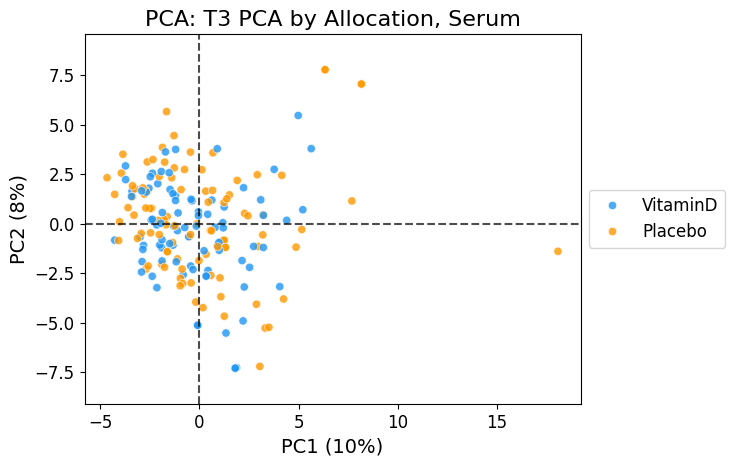

In [121]:
M3_vic['Allocation'] = M3_vic['Allocation_stage'].str.split('_').str[0]

apply_pca(M3_vic, "T3 PCA by Allocation, Serum", hue_col="Allocation",
          palette={
              "VitaminD": "#2196F3",
              "Placebo": "#FF9800"
          })

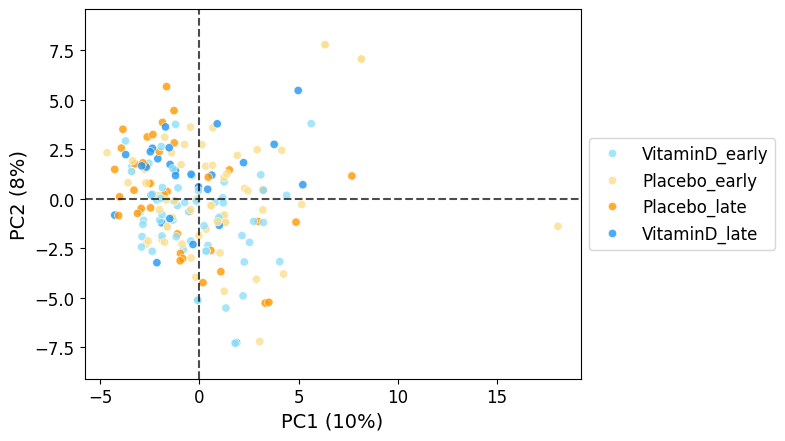

In [125]:
apply_pca(M3_vic, "T3 PCA by Treatment and Cancer Stage", hue_col="Allocation_stage", 
          palette = {
        "VitaminD_early": "#8FDFFA", 
        "VitaminD_late": "#2196F3",
        "Placebo_early": "#FADF8F",
        "Placebo_late": "#FF9800"},
          )

## Distance Matrix

euclidean

```python
skbio.stats.distance.permanova(distmat, grouping, column=None, permutations=999, seed=None)
```



In [43]:
#fill NAs in protein columns
M3_clean = M3_vic.dropna(subset=["Allocation_stage"]).reset_index(drop=True)
M3_clean["Allocation_stage"].value_counts()

#check
M3_clean["Allocation_stage"].value_counts()

Allocation_stage
Placebo_early     63
VitaminD_early    60
Placebo_late      38
VitaminD_late     28
Name: count, dtype: int64

In [44]:
# create distance matrix object
protein_data = M3_clean[list(protein_cols_perm)]
grouping = M3_clean["Allocation_stage"]


#make distance matrix
dist_square = squareform(pdist(protein_data, metric="euclidean"))
ids = M3_clean.index.astype(str).tolist() 
distmat = DistanceMatrix(dist_square, ids=ids)

In [45]:
grouping.index = distmat.ids

#run PERMANOVA
result = skbio.stats.distance.permanova(distmat, grouping, permutations=999)
print(result)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                     189
number of groups                  4
test statistic             1.457174
p-value                       0.004
number of permutations          999
Name: PERMANOVA results, dtype: object


## PERMANOVA at Baseline (Messzeitpunkt = 1.0) — CRC Stage only

In [46]:
# filter for Messzeitpunkt = 1.0 (baseline)
M1_vic = df_Stages[df_Stages["Messzeitpunkt"] == 1.0]

# delete Messzeitpunkt
M1_vic = M1_vic.drop(columns=["Messzeitpunkt"])

# Map stage numbers to early/late (CRC stage only, no treatment allocation)
M1_vic["stage_group"] = M1_vic["stage"].map(stage_map)

# drop stage and Alllocation (not testing treatment here)
M1_vic = M1_vic.drop(columns=["stage", "Alllocation"])

M1_vic.shape


(322, 329)

In [47]:
#fill NAs in protein columns
M1_clean = M1_vic.dropna(subset=["stage_group"]).reset_index(drop=True)
M1_clean["stage_group"].value_counts()


stage_group
early    194
late     115
Name: count, dtype: int64

In [48]:
# create distance matrix object
protein_data_M1 = M1_clean[list(protein_cols_perm)]
grouping_M1 = M1_clean["stage_group"]

#make distance matrix
dist_square_M1 = squareform(pdist(protein_data_M1, metric="euclidean"))
ids_M1 = M1_clean.index.astype(str).tolist()
distmat_M1 = DistanceMatrix(dist_square_M1, ids=ids_M1)


In [49]:
grouping_M1.index = distmat_M1.ids

#run PERMANOVA (CRC stage only, at baseline)
result_M1 = skbio.stats.distance.permanova(distmat_M1, grouping_M1, permutations=999)
print(result_M1)


method name               PERMANOVA
test statistic name        pseudo-F
sample size                     309
number of groups                  2
test statistic             4.070435
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object


we should not be splitting the data like this - your earlier permanova already showed sig. effect right? or was that somewhere else? maybe im getting confused now


from emily: it's right to try to dig deeper after getting a significant result, but you'd want to do that with a different kind of statistics, not the same one. ie don't follow up a permanova by a permanova 

## PERMANOVA only on Significant proteins

In [50]:
M3_clean_sig = M3_vic.dropna(subset=["Allocation_stage"]).reset_index(drop=True)
M3_clean_sig["treatment"] = M3_clean_sig["Allocation_stage"].str.split("_").str[0]

# Only significant proteins
protein_data = M3_clean_sig[list(sig_proteins)]
dist_square = squareform(pdist(protein_data, metric="euclidean"))
ids = M3_clean_sig.index.astype(str).tolist()
distmat = DistanceMatrix(dist_square, ids=ids)
grouping_treatment = M3_clean_sig["treatment"].copy()
grouping_treatment.index = ids
result_treatment = skbio.stats.distance.permanova(distmat, grouping_treatment, permutations=999)
print(result_treatment)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                     189
number of groups                  2
test statistic             1.410579
p-value                        0.11
number of permutations          999
Name: PERMANOVA results, dtype: object


In [51]:
M3_clean["Allocation_stage"].value_counts()

Allocation_stage
Placebo_early     63
VitaminD_early    60
Placebo_late      38
VitaminD_late     28
Name: count, dtype: int64

In [52]:
mask = M3_clean["Allocation_stage"].isin(["VitaminD_early", "VitaminD_late"]).values
M3_vitd = M3_clean[mask].reset_index(drop=True)

In [53]:
M3_clean = M3_clean.reset_index(drop=True)

In [54]:
M3_clean.index.duplicated().sum()
M3_clean[M3_clean.index.duplicated(keep=False)]

,name_from_intensity,A0A075B6H7,A0A075B6H9,A0A075B6I0,A0A075B6I1,A0A075B6I9,A0A075B6J9,A0A075B6K4,A0A075B6K5,A0A075B6P5,...,Q9HDC9,Q9NPH3,Q9NQ79,Q9NZP8,Q9UGM5,Q9UHG3,Q9UK55,Q9Y5Y7,Q9Y6R7,Allocation_stage


In [55]:
protein_cols.remove("batch_info")

In [56]:
mask = M3_clean["Allocation_stage"].isin(["VitaminD_early", "VitaminD_late"]).values
M3_vitd = M3_clean[mask].reset_index(drop=True)
M3_clean = M3_clean.reset_index(drop=True)
M3_clean.index.duplicated().sum()
M3_clean[M3_clean.index.duplicated(keep=False)]

,name_from_intensity,A0A075B6H7,A0A075B6H9,A0A075B6I0,A0A075B6I1,A0A075B6I9,A0A075B6J9,A0A075B6K4,A0A075B6K5,A0A075B6P5,...,Q9HDC9,Q9NPH3,Q9NQ79,Q9NZP8,Q9UGM5,Q9UHG3,Q9UK55,Q9Y5Y7,Q9Y6R7,Allocation_stage


In [57]:
# VitaminD early cancer Stage vs late Stage (effect of Stage within VitaminD)


protein_data_vitd = M3_vitd[list(protein_cols)]
dist_square_vitd = squareform(pdist(protein_data_vitd, metric="euclidean"))
ids_vitd = M3_vitd.index.astype(str).tolist()
distmat_vitd = DistanceMatrix(dist_square_vitd, ids=ids_vitd)

grouping_vitd = M3_vitd["Allocation_stage"].copy()
grouping_vitd.index = ids_vitd

result_vitd = skbio.stats.distance.permanova(distmat_vitd, grouping_vitd, permutations=999)
print("VitaminD early CRC stage vs late:")
print(result_vitd)

VitaminD early CRC stage vs late:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      88
number of groups                  2
test statistic              1.78405
p-value                       0.004
number of permutations          999
Name: PERMANOVA results, dtype: object


In [58]:
M3_early = M3_clean[M3_clean["Allocation_stage"].isin(["Placebo_early", "VitaminD_early"]).values].reset_index(drop=True)
protein_data_early = M3_early[list(protein_cols)]
dist_square_early = squareform(pdist(protein_data_early, metric="euclidean"))
ids_early = M3_early.index.astype(str).tolist()
distmat_early = DistanceMatrix(dist_square_early, ids=ids_early)
grouping_early = M3_early["Allocation_stage"].copy()
grouping_early.index = ids_early
result_early = skbio.stats.distance.permanova(distmat_early, grouping_early, permutations=999)
print("Placebo vs VitaminD, early stage only:")
print(result_early)

Placebo vs VitaminD, early stage only:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     123
number of groups                  2
test statistic             1.641738
p-value                       0.017
number of permutations          999
Name: PERMANOVA results, dtype: object


In [59]:
M3_late = M3_clean[M3_clean["Allocation_stage"].isin(["Placebo_late", "VitaminD_late"]).values].reset_index(drop=True)
protein_data_late = M3_late[list(protein_cols)]
dist_square_late = squareform(pdist(protein_data_late, metric="euclidean"))
ids_late = M3_late.index.astype(str).tolist()
distmat_late = DistanceMatrix(dist_square_late, ids=ids_late)
grouping_late = M3_late["Allocation_stage"].copy()
grouping_late.index = ids_late
result_late = skbio.stats.distance.permanova(distmat_late, grouping_late, permutations=999)
print("Placebo vs VitaminD, late stage only:")
print(result_late)

Placebo vs VitaminD, late stage only:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      66
number of groups                  2
test statistic             0.899328
p-value                       0.656
number of permutations          999
Name: PERMANOVA results, dtype: object


In [60]:
# Overall Placebo vs VitaminD (stage pooled)
M3_treatment = M3_clean.copy()
M3_treatment["Treatment"] = M3_treatment["Allocation_stage"].str.split("_").str[0]  # "Placebo" or "VitaminD"

protein_data_treatment = M3_treatment[list(protein_cols)]
dist_square_treatment = squareform(pdist(protein_data_treatment, metric="euclidean"))
ids_treatment = M3_treatment.index.astype(str).tolist()
distmat_treatment = DistanceMatrix(dist_square_treatment, ids=ids_treatment)
grouping_treatment = M3_treatment["Treatment"].copy()
grouping_treatment.index = ids_treatment
result_treatment = skbio.stats.distance.permanova(distmat_treatment, grouping_treatment, permutations=999)
print("Placebo vs VitaminD, overall (stage pooled):")
print(result_treatment)

Placebo vs VitaminD, overall (stage pooled):
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     189
number of groups                  2
test statistic             1.120271
p-value                       0.243
number of permutations          999
Name: PERMANOVA results, dtype: object


In [61]:
M3_placebo = M3_clean[M3_clean["Allocation_stage"].isin(["Placebo_early", "Placebo_late"]).values].reset_index(drop=True)
protein_data_placebo = M3_placebo[list(protein_cols)]
dist_square_placebo = squareform(pdist(protein_data_placebo, metric="euclidean"))
ids_placebo = M3_placebo.index.astype(str).tolist()
distmat_placebo = DistanceMatrix(dist_square_placebo, ids=ids_placebo)
grouping_placebo = M3_placebo["Allocation_stage"].copy()
grouping_placebo.index = ids_placebo
result_placebo = skbio.stats.distance.permanova(distmat_placebo, grouping_placebo, permutations=999)
print("Placebo early vs late stage:")
print(result_placebo)

Placebo early vs late stage:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     101
number of groups                  2
test statistic              1.48775
p-value                       0.036
number of permutations          999
Name: PERMANOVA results, dtype: object


## post-Hoc Test

In [62]:
#!wget https://raw.githubusercontent.com/ivanp1994/PyPerMANOVA/main/PyPerMANOVA.py

In [63]:
!sed -i 's/from scipy.stats.stats import _unequal_var_ttest_denom/from scipy.stats._stats_py import _unequal_var_ttest_denom/' ~/Scrips_Bachelor_Thesis/PyPerMANOVA.py

In [64]:
#copy PyPerMANOVA Github
from PyPerMANOVA import permutational_analysis

permanova_result, posthoc_result = permutational_analysis(
    data=M3_clean[list(protein_cols_perm)].T,
    mapping=M3_clean["Allocation_stage"],
    norm="row",
    metric="euclidean",
    permutations=999
)

# recalculate with FDR-BH instead of Bonferroni
_, fdr_pvals, _, _ = multipletests(posthoc_result['Pval'], method='fdr_bh')
posthoc_result['fdr'] = fdr_pvals

print(permanova_result)
print(posthoc_result[['A', 'B', 'Pval', 'bonf', 'fdr', 'eta-sqr', 'cohen-d']])

    Pval  eta-sqr        F
0  0.001  0.02471  1.56242
                A              B   Pval   bonf     fdr   eta-sqr   cohen-d
0  VitaminD_early  Placebo_early  0.009  0.054  0.0270  0.014360  0.241770
1  VitaminD_early   Placebo_late  0.018  0.108  0.0360  0.017580  0.279697
2  VitaminD_early  VitaminD_late  0.001  0.006  0.0060  0.026877  0.360333
3   Placebo_early   Placebo_late  0.112  0.672  0.1680  0.013070  0.237157
4   Placebo_early  VitaminD_late  0.379  2.274  0.3790  0.011329  0.227470
5    Placebo_late  VitaminD_late  0.184  1.104  0.2208  0.017709  0.270054


check out 

* https://github.com/ivanp1994/PyPerMANOVA/blob/main/PyPerMANOVA.py

* https://pypi.org/project/scikit-posthocs/

as possible alternatives

## PCOA

consider adding a PCoA to follow these results with the distance matrix as the input to the PCoA 

In [67]:
prot_all = M3_clean[list(protein_cols_perm)]
dist_sq_all = squareform(pdist(prot_all, metric="euclidean"))
ids_all = M3_clean.index.astype(str).tolist()
dm_all = DistanceMatrix(dist_sq_all, ids=ids_all)

pcoa_result = pcoa(dm_all)
pcoa_df = pcoa_result.samples[["PC1", "PC2"]].copy()
pcoa_df["Allocation_stage"] = M3_clean["Allocation_stage"].values
pc1_var = pcoa_result.proportion_explained.iloc[0] * 100
pc2_var = pcoa_result.proportion_explained.iloc[1] * 100

print(pcoa_df["Allocation_stage"].value_counts())
print(f"PC1: {pc1_var:.1f}%, PC2: {pc2_var:.1f}%")

# get group centroids for plotting
centroids = pcoa_df.groupby("Allocation_stage")[["PC1","PC2"]].mean()
print(centroids)

Allocation_stage
Placebo_early     63
VitaminD_early    60
Placebo_late      38
VitaminD_late     28
Name: count, dtype: int64
PC1: 10.0%, PC2: 8.4%
                       PC1       PC2
Allocation_stage                    
Placebo_early    -0.636859  0.439950
Placebo_late      0.816578  0.101106
VitaminD_early   -0.111609 -0.903077
VitaminD_late     0.563882  0.808063


/home/mvoss/.local/lib/python3.10/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(


In [68]:
centroids = pcoa_df.groupby("Allocation_stage")[["PC1","PC2"]].mean()

distances = []
for idx, row in pcoa_df.iterrows():
    group = row["Allocation_stage"]
    centroid = centroids.loc[group].values.astype(float).reshape(1, -1)
    sample = row[["PC1","PC2"]].values.astype(float).reshape(1, -1)
    dist = cdist(sample, centroid, metric="euclidean")[0][0]
    distances.append(dist)

pcoa_df["dist_to_centroid"] = distances
print(pcoa_df.head())
print(pcoa_df.groupby("Allocation_stage")["dist_to_centroid"].mean())

         PC1       PC2 Allocation_stage  dist_to_centroid
0  -0.969446 -1.933886   VitaminD_early          1.341064
1   0.953022 -1.084824   VitaminD_early          1.080033
2 -18.211310  1.485427    Placebo_early         17.605520
3  -7.612034  2.391595     Placebo_late          8.734291
4  -3.126364  0.844392     Placebo_late          4.012389
Allocation_stage
Placebo_early     3.572651
Placebo_late      3.384520
VitaminD_early    2.747718
VitaminD_late     2.828281
Name: dist_to_centroid, dtype: float64


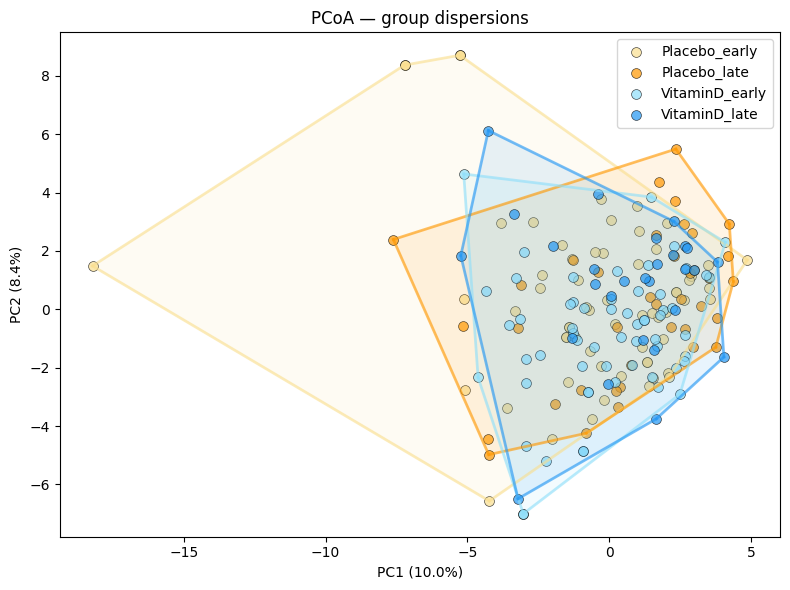

In [69]:
#color palette
custom_palette = {
    "VitaminD_early": "#8FDFFA",  # blue
    "Placebo_early": "#FADF8F",   # orange/yellow
    "VitaminD_late": "#2196F3",
    "Placebo_late": "#FF9800"
}

available_groups = [group for group in pcoa_df["Allocation_stage"].unique() 
                    if group in custom_palette]
colors = {group: custom_palette[group] for group in available_groups}

fig, ax = plt.subplots(figsize=(8, 6))

for group, df in pcoa_df.groupby("Allocation_stage"):
    if group not in colors:
        continue 
    
    # Plot points
    ax.scatter(df["PC1"], df["PC2"], label=group, alpha=0.7,
               color=colors[group], edgecolors='k', linewidths=0.5, s=50)
    
    # convex hull if enough points (need at least 3)
    if len(df) >= 3:
        hull = ConvexHull(df[["PC1", "PC2"]].values)
        for simplex in hull.simplices:
            ax.plot(df["PC1"].iloc[simplex], df["PC2"].iloc[simplex], 
                   color=colors[group], linewidth=2, alpha=0.6)
        # Fill the hull
        hull_points = df[["PC1", "PC2"]].values[hull.vertices]
        ax.fill(hull_points[:, 0], hull_points[:, 1], 
                color=colors[group], alpha=0.1)

# Labels and title
pc1_var = pcoa_result.proportion_explained.iloc[0] * 100
pc2_var = pcoa_result.proportion_explained.iloc[1] * 100
ax.set_xlabel(f"PC1 ({pc1_var:.1f}%)")
ax.set_ylabel(f"PC2 ({pc2_var:.1f}%)")
ax.legend()
ax.set_title("PCoA — group dispersions")
plt.tight_layout()
plt.show()

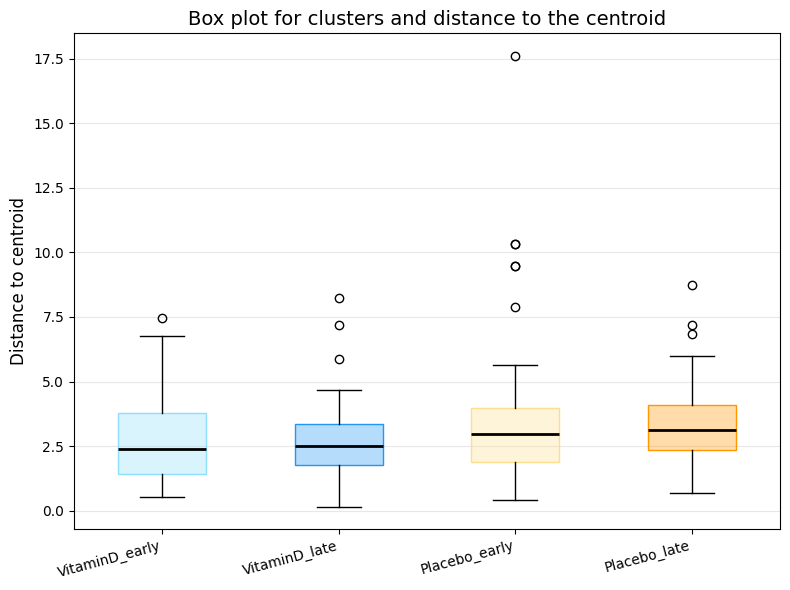

In [70]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = {
    "VitaminD_early": "#8FDFFA",  # blue
    "VitaminD_late": "#2196F3",
    "Placebo_early": "#FADF8F",   # orange/yellow
    "Placebo_late": "#FF9800"
}

groups_order = ["VitaminD_early", "VitaminD_late", "Placebo_early", "Placebo_late"]
data_box = [pcoa_df[pcoa_df["Allocation_stage"] == g]["dist_to_centroid"].values for g in groups_order]
bp = ax.boxplot(data_box, patch_artist=True, widths=0.5)

for patch, g in zip(bp['boxes'], groups_order):
    patch.set_facecolor(colors[g] + '55')  
    patch.set_edgecolor(colors[g])

for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax.set_xticks(range(1, 5))
ax.set_xticklabels(groups_order, rotation=15, ha='right', fontsize=10)
ax.set_ylabel("Distance to centroid", fontsize=12)
ax.set_title("Box plot for clusters and distance to the centroid", fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [71]:
## identify drivers of the clusters
#we know sig: vitamin d early stage vs placebo early stage
# sig: vit d early stage vs vit d late stage

#https://aacrjournals.org/cancerres/article/86/7_Supplement/7699/781911
#Differential protein abundance can be assessed using a one-factor analysis with |fold change| ≥1.5 and p≤0.05.
#Dysregulated proteins were annotated using UniProt and Ingenuity Pathway Analysis (IPA)


## K-means Clustering

In [72]:
protein_columns = protein_cols[:-1]

In [73]:
scaler = StandardScaler()
prot_scaled = scaler.fit_transform(M3_clean[list(protein_columns)])

kmeans = KMeans(n_clusters=4, init="k-means++", n_init=50, max_iter=500, random_state=42)
M3_clean["KMeans_cluster"] = kmeans.fit_predict(prot_scaled)

#see k clusters with actual cluster numbers
print(pd.crosstab(M3_clean["Allocation_stage"], M3_clean["KMeans_cluster"], margins=True))

KMeans_cluster     0   1   2  3  All
Allocation_stage                    
Placebo_early     10  26  22  5   63
Placebo_late       8  16  14  0   38
VitaminD_early    13  14  32  1   60
VitaminD_late      6  15   6  1   28
All               37  71  74  7  189


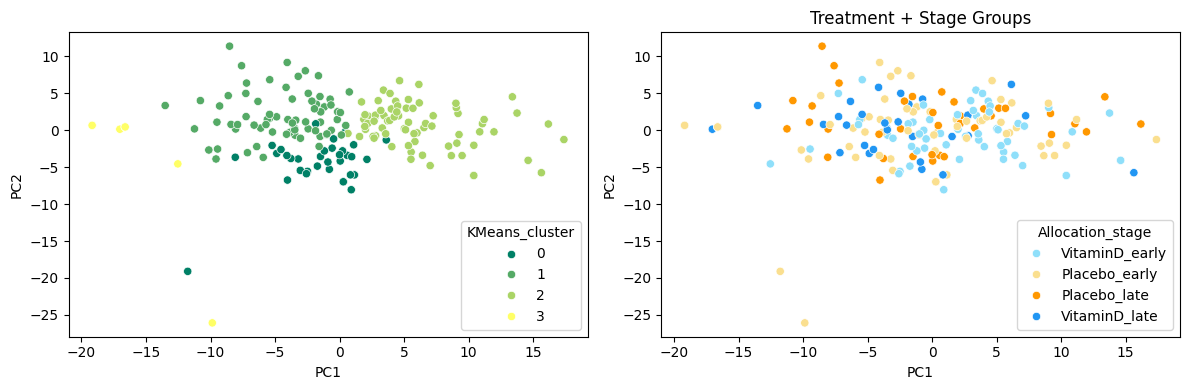

Variance explained: PC1=13.8%, PC2=5.4%


In [74]:
#make plot to see the clusters
custom_palette = {
        "VitaminD_early": "#8FDFFA", #blue
        "VitaminD_late": "#2196F3",
        "Placebo_early": "#FADF8F", #orange/yellow
        "Placebo_late": "#FF9800"
    }
pca = PCA(n_components=2)
coords = pca.fit_transform(prot_scaled)

M3_clean["PC1"] = coords[:, 0]
M3_clean["PC2"] = coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=M3_clean, x="PC1", y="PC2", hue="KMeans_cluster", palette="summer", ax=axes[0])


sns.scatterplot(data=M3_clean, x="PC1", y="PC2", hue="Allocation_stage", palette=custom_palette, ax=axes[1])
axes[1].set_title("Treatment + Stage Groups")

plt.tight_layout()
plt.savefig("K-means_cluster_vs_actual.png", dpi=300)
plt.show()

print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}")

## Mann-Whitney U test for significant results from PERMANOVA
VitaminD_early vs Placebo_early
VitaminD_early vs VitaminD_late


In [75]:
#M3_clean

In [76]:
# Early stage cancer Placebo vs VitaminD
M3_clean = M3_clean.reset_index(drop=True)
group_a = M3_clean[M3_clean['Allocation_stage'] == 'VitaminD_early']
group_b = M3_clean[M3_clean['Allocation_stage'] == 'Placebo_early']

whitney_results = []
for protein in protein_columns:
    stat, p = stats.mannwhitneyu(group_a[protein], group_b[protein], alternative='two-sided')
    whitney_results.append({'protein': protein, 'stat': stat, 'p_value': p})

whitney_results = pd.DataFrame(whitney_results).sort_values('p_value')
whitney_results = whitney_results.dropna(subset=['p_value'])
reject, p_adj, _, _ = multipletests(whitney_results['p_value'], method='fdr_bh')
whitney_results['p_adj'] = p_adj
whitney_results['significant'] = reject

print(f"Total proteins tested: {len(whitney_results)}")
print(f"Significant after FDR correction: {whitney_results['significant'].sum()}")
print(f"Proportion significant: {whitney_results['significant'].mean():.1%}")
whitney_results[whitney_results['significant']].sort_values('p_adj')

Total proteins tested: 326
Significant after FDR correction: 0
Proportion significant: 0.0%


,protein,stat,p_value,p_adj,significant


Total proteins tested: 326
Significant after FDR correction: 0
Proportion significant: 0.0%


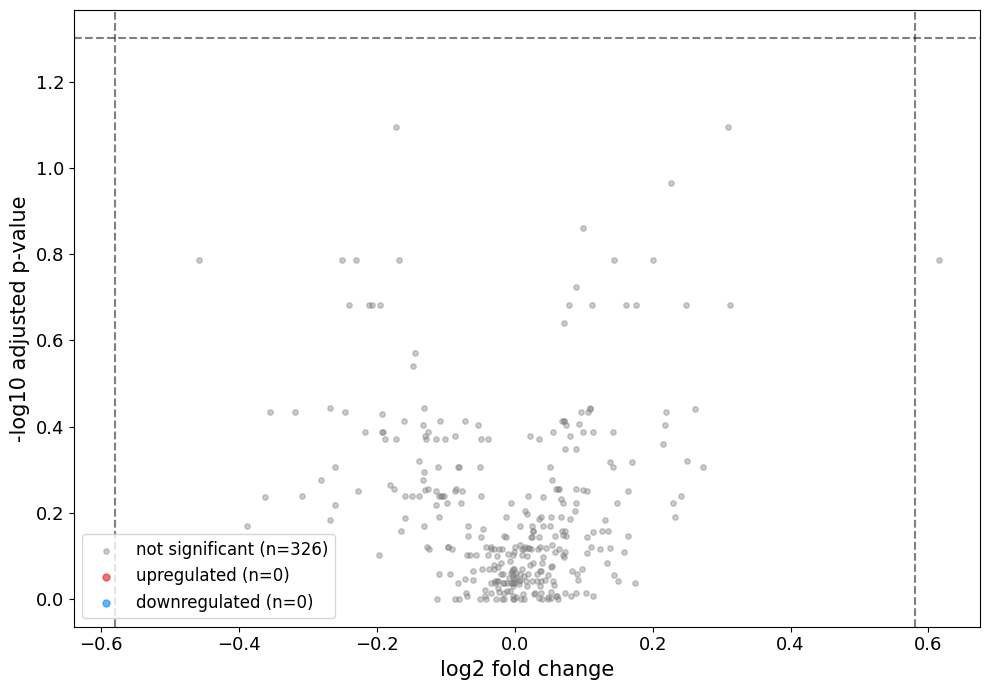

In [78]:
# Early stage cancer Placebo vs VitaminD
M3_clean = M3_clean.reset_index(drop=True)
group_b = M3_clean[M3_clean['Allocation_stage'] == 'Placebo_early']
group_a = M3_clean[M3_clean['Allocation_stage'] == 'VitaminD_early']

whitney_results = []
for protein in protein_columns:
    stat, p = stats.mannwhitneyu(group_b[protein], group_a[protein], alternative='two-sided')
    whitney_results.append({'protein': protein, 'stat': stat, 'p_value': p})

whitney_results = pd.DataFrame(whitney_results).sort_values('p_value')
whitney_results = whitney_results.dropna(subset=['p_value'])
reject, p_adj, _, _ = multipletests(whitney_results['p_value'], method='fdr_bh')
whitney_results['p_adj'] = p_adj
whitney_results['significant'] = reject

print(f"Total proteins tested: {len(whitney_results)}")
print(f"Significant after FDR correction: {whitney_results['significant'].sum()}")
print(f"Proportion significant: {whitney_results['significant'].mean():.1%}")
whitney_results[whitney_results['significant']].sort_values('p_adj')

# add log2fc and -log10 p_adj to whitney_results first
fold_changes = []
for protein in whitney_results['protein']:
    med_placebo = group_b[protein].median()
    med_vitd = group_a[protein].median()
    fold_changes.append(med_vitd - med_placebo)  # VitaminD vs Placebo
whitney_results['log2fc'] = fold_changes
whitney_results['-log10_p_adj'] = -np.log10(whitney_results['p_adj'])

# volcano plot
FC_THRESH = 0.58
PVAL_THRESH = 0.05
def classify(row):
    if not row['significant'] or abs(row['log2fc']) < FC_THRESH:
        return 'not significant'
    elif row['log2fc'] > FC_THRESH:
        return 'upregulated'  # Higher in VitaminD
    else:
        return 'downregulated'  # Higher in Placebo

whitney_results['direction'] = whitney_results.apply(classify, axis=1)
color_map = {
    'not significant': 'grey',
    'upregulated':     '#E53935',
    'downregulated':   '#2196F3',
}
fig, ax = plt.subplots(figsize=(10, 7))
for group, color in color_map.items():
    subset = whitney_results[whitney_results['direction'] == group]
    ax.scatter(subset['log2fc'], subset['-log10_p_adj'],
               color=color, alpha=0.7 if group != 'not significant' else 0.4,
               s=25 if group != 'not significant' else 15,
               label=f"{group} (n={len(subset)})")
ax.axhline(y=-np.log10(PVAL_THRESH), color='black', ls='--', alpha=0.5)
ax.axvline(x= FC_THRESH, color='black', ls='--', alpha=0.5)
ax.axvline(x=-FC_THRESH, color='black', ls='--', alpha=0.5)
for _, row in whitney_results[whitney_results['direction'] != 'not significant'].iterrows():
    ax.annotate(row['protein'], xy=(row['log2fc'], row['-log10_p_adj']),
                fontsize=10, ha='left', va='bottom')
ax.set_xlabel('log2 fold change', fontsize=15)
ax.set_ylabel('-log10 adjusted p-value', fontsize=15)
#ax.set_title('Volcano plot: VitaminD vs Placebo (early stage cancer)', fontsize=17)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig("volcano_whitney_vitd_vs_placebo_early.png", dpi=150)
plt.show()

In [79]:
# Early stage cancer VitaminD vs late VitaminD
group_c = M3_clean[M3_clean['Allocation_stage'] == 'VitaminD_late']

whitney_results = []
for protein in protein_columns:
    stat, p = stats.mannwhitneyu(group_a[protein], group_c[protein], alternative='two-sided')
    whitney_results.append({'protein': protein, 'stat': stat, 'p_value': p})

whitney_results = pd.DataFrame(whitney_results).sort_values('p_value')
whitney_results = whitney_results.dropna(subset=['p_value'])
reject, p_adj, _, _ = multipletests(whitney_results['p_value'], method='fdr_bh')
whitney_results['p_adj'] = p_adj
whitney_results['significant'] = reject

print(f"Total proteins tested: {len(whitney_results)}")
print(f"Significant after FDR correction: {whitney_results['significant'].sum()}")
print(f"Proportion significant: {whitney_results['significant'].mean():.1%}")
whitney_results[whitney_results['significant']].sort_values('p_adj')

Total proteins tested: 326
Significant after FDR correction: 2
Proportion significant: 0.6%


,protein,stat,p_value,p_adj,significant
172,P05546,1302.0,0.000036,0.011598,True
296,Q14624,1252.0,0.000227,0.037054,True


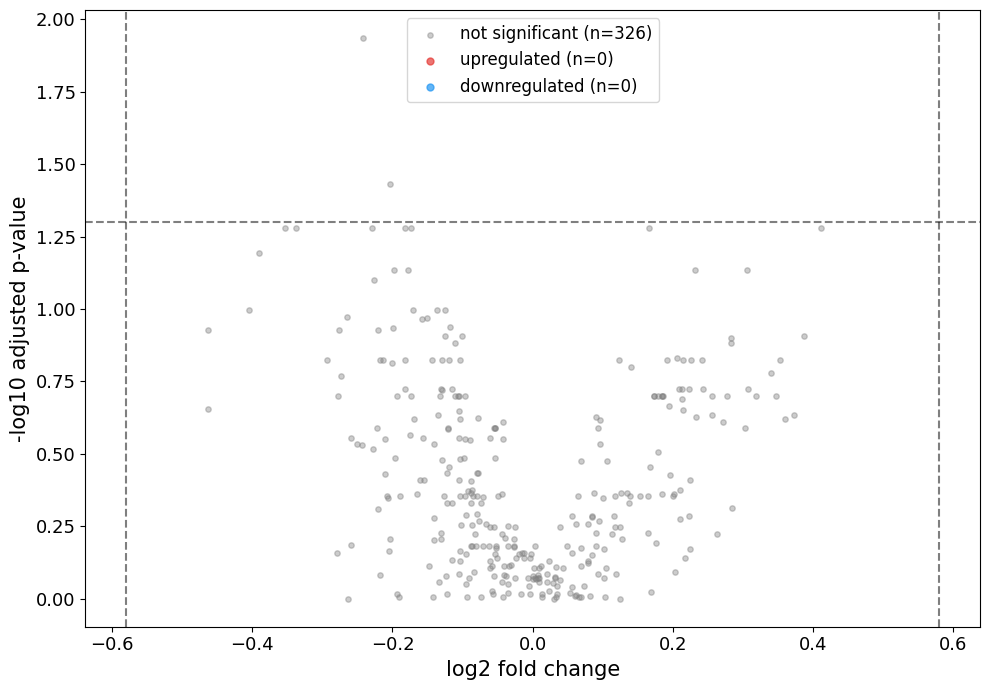

In [80]:
# add log2fc and -log10 p_adj to whitney_results first
fold_changes = []
for protein in whitney_results['protein']:
    med_early = group_a[protein].median()
    med_late  = group_c[protein].median()
    fold_changes.append(med_late - med_early)
whitney_results['log2fc'] = fold_changes
whitney_results['-log10_p_adj'] = -np.log10(whitney_results['p_adj'])
# volcano plot
FC_THRESH = 0.58
PVAL_THRESH = 0.05
def classify(row):
    if not row['significant'] or abs(row['log2fc']) < FC_THRESH:
        return 'not significant'
    elif row['log2fc'] > FC_THRESH:
        return 'upregulated'
    else:
        return 'downregulated'
whitney_results['direction'] = whitney_results.apply(classify, axis=1)
color_map = {
    'not significant': 'grey',
    'upregulated':     '#E53935',
    'downregulated':   '#2196F3',
}
fig, ax = plt.subplots(figsize=(10, 7))
for group, color in color_map.items():
    subset = whitney_results[whitney_results['direction'] == group]
    ax.scatter(subset['log2fc'], subset['-log10_p_adj'],
               color=color, alpha=0.7 if group != 'not significant' else 0.4,
               s=25 if group != 'not significant' else 15,
               label=f"{group} (n={len(subset)})")
ax.axhline(y=-np.log10(PVAL_THRESH), color='black', ls='--', alpha=0.5)
ax.axvline(x= FC_THRESH, color='black', ls='--', alpha=0.5)
ax.axvline(x=-FC_THRESH, color='black', ls='--', alpha=0.5)
for _, row in whitney_results[whitney_results['direction'] != 'not significant'].iterrows():
    ax.annotate(row['protein'], xy=(row['log2fc'], row['-log10_p_adj']),
                fontsize=10, ha='left', va='bottom')
ax.set_xlabel('log2 fold change', fontsize=15)
ax.set_ylabel('-log10 adjusted p-value', fontsize=15)
#ax.set_title('Volcano plot: VitaminD early vs late stage', fontsize=17)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig("volcano_serum_early_late_vitD.png", dpi=150)
plt.show()

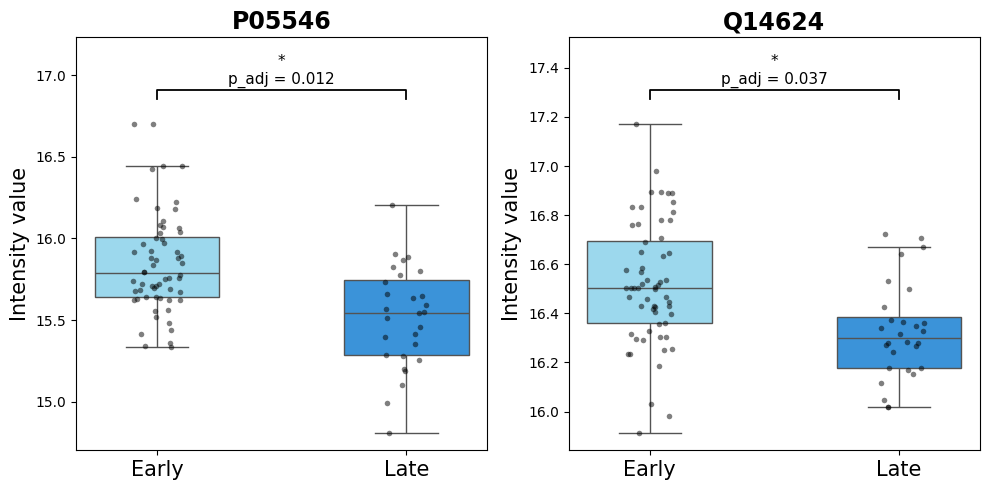

In [83]:
from scipy.stats import mannwhitneyu

# make bar plot for significant proteins
## P05546
## Q14624
proteins_of_interest = ["P05546", "Q14624"]
plot_data = M3_clean[M3_clean["Allocation_stage"].isin(["VitaminD_early", "VitaminD_late"])][["Allocation_stage"] + proteins_of_interest].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, protein in zip(axes, proteins_of_interest):
    sns.boxplot(
        data=plot_data,
        x="Allocation_stage",
        y=protein,
        hue="Allocation_stage",
        palette={"VitaminD_early": "#8FDFFA", "VitaminD_late": "#2196F3"},
        order=["VitaminD_early", "VitaminD_late"],
        legend=False,
        width=0.5,
        showfliers=False,
        ax=ax
    )
    sns.stripplot(
        data=plot_data,
        x="Allocation_stage",
        y=protein,
        color="black",
        size=4,
        alpha=0.5,
        order=["VitaminD_early", "VitaminD_late"],
        ax=ax
    )

    # --- look up BH-FDR adjusted p-value for this protein from whitney_results ---
    q_val = whitney_results.loc[whitney_results["protein"] == protein, "p_adj"].values[0]

    if q_val < 0.001:
        q_text = "p_adj < 0.001"
    else:
        q_text = f"p_adj = {q_val:.3f}"

    if q_val < 0.001:
        stars = "***"
    elif q_val < 0.01:
        stars = "**"
    elif q_val < 0.05:
        stars = "*"
    else:
        stars = "ns"

    y_max = plot_data[protein].max()
    y_min = plot_data[protein].min()
    y_range = y_max - y_min
    bracket_y = y_max + 0.08 * y_range
    bracket_h = 0.03 * y_range

    ax.plot([0, 0, 1, 1],
            [bracket_y, bracket_y + bracket_h, bracket_y + bracket_h, bracket_y],
            lw=1.3, color="black")
    ax.text(0.5, bracket_y + bracket_h * 1.2, f"{stars}\n{q_text}",
            ha="center", va="bottom", fontsize=11)

    ax.set_ylim(top=bracket_y + 0.2 * y_range)
    ax.set_title(protein, fontsize=17, fontweight="bold")
    ax.set_xlabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Early", "Late"], fontsize=15)
    ax.set_ylabel("Intensity value", fontsize=15)

#plt.suptitle("VitaminD early and late Stage CRC with significant proteins", fontsize=17, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("boxplot_vitd_early_late.png", dpi=150, bbox_inches="tight")
plt.show()

In [91]:
for protein in proteins_of_interest:
    match = whitney_results.loc[whitney_results["protein"] == protein, "p_adj"]
    print(protein, "-> matches found:", len(match), "-> values:", match.values)

P05546 -> matches found: 1 -> values: [0.01159802]
Q14624 -> matches found: 1 -> values: [0.03705436]
